- We have two types of scaling

    - Z score (Standardization)
 
    - Min max scalar (Normalization)

**Z score**

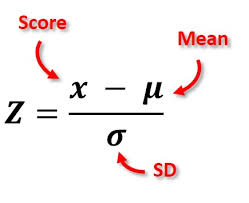

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
data = r"C:\Users\Lenovo\Documents\NareshIT\Data_files\Visadataset.csv"
visa_df = pd.read_csv(data)
cat = visa_df.select_dtypes(include='object')
num = visa_df.select_dtypes(exclude='object')

In [36]:
wage_data = visa_df['prevailing_wage']
Mean = np.mean(wage_data)
Std = np.std(wage_data)
Nr = wage_data - Mean
z_Wage = Nr/Std
visa_df['z_Wage'] = z_Wage

In [37]:
visa_df[['prevailing_wage','z_Wage']]

,prevailing_wage,z_Wage
0,592.2029,-1.398537
1,83425.6500,0.169835
2,122996.8600,0.919079
3,83434.0300,0.169994
4,149907.3900,1.428604
...,...,...
25475,77092.5700,0.049924
25476,279174.7900,3.876159
25477,146298.8500,1.360280
25478,86154.7700,0.221509


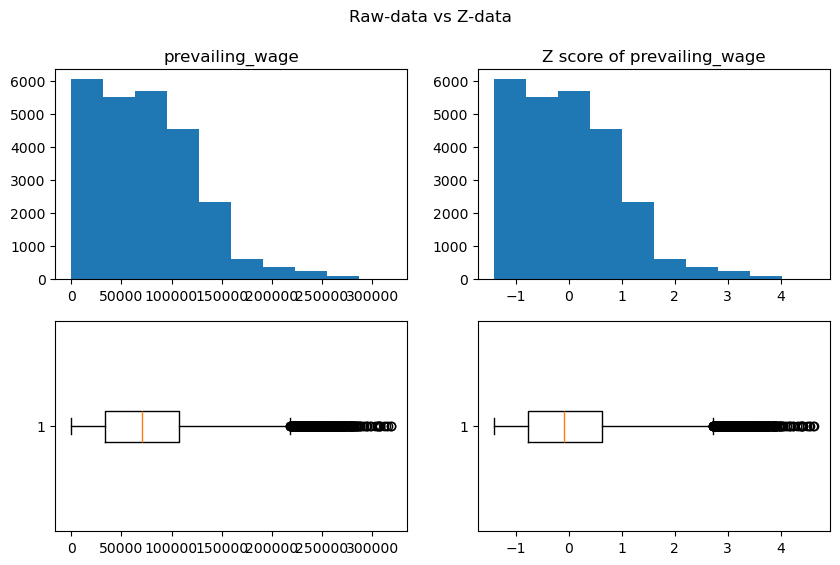

In [38]:
plt.figure(figsize=(10,6))
plt.suptitle('Raw-data vs Z-data')
plt.subplot(2,2,1).hist(wage_data)
plt.title('prevailing_wage')
plt.subplot(2,2,2).hist(z_Wage)
plt.title('Z score of prevailing_wage')
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(z_Wage,vert=False)
plt.show()

**StandardScalar**

- sklearn

    - preprocessing
 
        - StandardScalar

In [39]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit_transform(visa_df['prevailing_wage'])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [40]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
wage_ss = ss.fit_transform(visa_df[['prevailing_wage']])
visa_df['wage_ss'] = wage_ss

In [41]:
visa_df[['prevailing_wage']]

,prevailing_wage
0,592.2029
1,83425.6500
2,122996.8600
3,83434.0300
4,149907.3900
...,...
25475,77092.5700
25476,279174.7900
25477,146298.8500
25478,86154.7700


In [42]:
visa_df[['prevailing_wage','z_Wage','wage_ss']]

,prevailing_wage,z_Wage,wage_ss
0,592.2029,-1.398537,-1.398537
1,83425.6500,0.169835,0.169835
2,122996.8600,0.919079,0.919079
3,83434.0300,0.169994,0.169994
4,149907.3900,1.428604,1.428604
...,...,...,...
25475,77092.5700,0.049924,0.049924
25476,279174.7900,3.876159,3.876159
25477,146298.8500,1.360280,1.360280
25478,86154.7700,0.221509,0.221509


In [43]:
visa_df
visa_df['prevailing_wage']
visa_df['prevailing_wage'].values
visa_df['prevailing_wage'].values.reshape(-1,1)

array([[   592.2029],
       [ 83425.65  ],
       [122996.86  ],
       ...,
       [146298.85  ],
       [ 86154.77  ],
       [ 70876.91  ]])

In [44]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
wage_ss = ss.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))
wage_ss

array([[-1.39853722],
       [ 0.1698353 ],
       [ 0.91907852],
       ...,
       [ 1.36027953],
       [ 0.22150859],
       [-0.06776315]])

**Min Max Scalar**

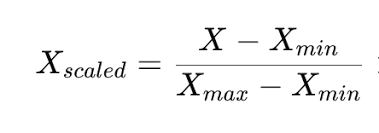

In [56]:
wage_data = visa_df['prevailing_wage']
Min = wage_data.min()
Max = wage_data.max()
Nr = wage_data - Min
Dr = Max - Min
max(Nr/Dr),min(Nr/Dr)
visa_df['wage_min_max'] = Nr/Dr

In [58]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
mms.fit_transform(visa_df[['prevailing_wage']])
mms.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))

array([[0.00184853],
       [0.2613452 ],
       [0.385312  ],
       ...,
       [0.45831136],
       [0.26989486],
       [0.22203311]])

In [60]:
visa_df[['prevailing_wage','wage_min_max']]

,prevailing_wage,wage_min_max
0,592.2029,0.001849
1,83425.6500,0.261345
2,122996.8600,0.385312
3,83434.0300,0.261371
4,149907.3900,0.469616
...,...,...
25475,77092.5700,0.241505
25476,279174.7900,0.874579
25477,146298.8500,0.458311
25478,86154.7700,0.269895
